# Natural Disasters Museum - Data Analysis & Processing
## EM-DAT Dataset: 1975-2025

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_PATH = Path('public_emdat_incl_hist_2026-03-17.xlsx')
SHEET_NAME = 'EM-DAT Data'
YEAR_START = 1975
YEAR_END = 2025

print(f'Natural Disasters Museum - Data Processing')
print(f'Analysis Period: {YEAR_START}-{YEAR_END}')
print(f'Dataset: {DATA_PATH.name}')

Natural Disasters Museum - Data Processing
Analysis Period: 1975-2025
Dataset: public_emdat_incl_hist_2026-03-17.xlsx


## 1. Data Loading & Preprocessing

In [2]:
df_full = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
print(f'Full dataset: {len(df_full):,} records')

# Filter to analysis period and natural disasters only
df = df_full[
    (df_full['Start Year'].between(YEAR_START, YEAR_END, inclusive='both')) &
    (df_full['Disaster Group'] == 'Natural')
].copy()

print(f'Filtered dataset ({YEAR_START}-{YEAR_END}, Natural disasters): {len(df):,} records')

# Create Disaster_ID (unique event identifier across countries)
df['Disaster_ID'] = df['DisNo.'].str.split('-').str[:2].str.join('-')

columns_to_keep = [
    'DisNo.', 'Disaster_ID', 'Historic', 'Event Name',
    'ISO', 'Country', 'Subregion', 'Region',
    'Latitude', 'Longitude',
    'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
    'Magnitude', 'Magnitude Scale',
    'Start Year', 'Start Month', 'Start Day',
    'End Year', 'End Month', 'End Day',
    'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected',
    'Total Damage, Adjusted (\'000 US$)',
    'Insured Damage, Adjusted (\'000 US$)',
    'Reconstruction Costs, Adjusted (\'000 US$)'
]

df_clean = df[columns_to_keep].copy()

print('\nDataset preview:')
df_clean.head()

Full dataset: 27,532 records
Filtered dataset (1975-2025, Natural disasters): 15,871 records

Dataset preview:


,DisNo.,Disaster_ID,Historic,Event Name,ISO,Country,Subregion,Region,Latitude,Longitude,...,End Month,End Day,Total Deaths,No. Injured,No. Affected,No. Homeless,Total Affected,"Total Damage, Adjusted ('000 US$)","Insured Damage, Adjusted ('000 US$)","Reconstruction Costs, Adjusted ('000 US$)"
2385,1975-0008-KEN,1975-0008,Yes,NaN,KEN,Kenya,Sub-Saharan Africa,Africa,NaN,NaN,...,NaN,NaN,NaN,NaN,16000.0,NaN,16000.0,NaN,NaN,NaN
2386,1975-0012-THA,1975-0012,Yes,NaN,THA,Thailand,South-eastern Asia,Asia,NaN,NaN,...,1.0,3.0,239.0,93.0,3000000.0,NaN,3000093.0,262298.0,NaN,NaN
2387,1975-0013-MDG,1975-0013,Yes,Deborah & Ines,MDG,Madagascar,Sub-Saharan Africa,Africa,NaN,NaN,...,1.0,NaN,7.0,50.0,10000.0,NaN,10050.0,NaN,NaN,NaN
2388,1975-0014-IND,1975-0014,Yes,NaN,IND,India,Southern Asia,Asia,32.455,78.43,...,1.0,19.0,47.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2389,1975-0015-FJI,1975-0015,Yes,Val,FJI,Fiji,Melanesia,Oceania,NaN,NaN,...,1.0,30.0,NaN,NaN,23000.0,NaN,23000.0,5829.0,NaN,NaN


In [3]:
print(f'Dataset shape: {df_clean.shape}')
print(f'Unique disasters (Disaster_ID): {df_clean["Disaster_ID"].nunique():,}')
print(f'Unique countries: {df_clean["Country"].nunique()}')
print(f'Time range: {df_clean["Start Year"].min()}-{df_clean["Start Year"].max()}')

missing = df_clean.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_clean) * 100).round(1)
missing_summary = pd.DataFrame({
    'Missing Count': missing[missing > 0],
    'Missing %': missing_pct[missing > 0]
})
print('\nMissing values:')
missing_summary.head(10)

Dataset shape: (15871, 30)
Unique disasters (Disaster_ID): 13,783
Unique countries: 230
Time range: 1975-2025

Missing values:


,Missing Count,Missing %
"Reconstruction Costs, Adjusted ('000 US$)",15831,99.7
"Insured Damage, Adjusted ('000 US$)",14739,92.9
No. Homeless,13579,85.6
Latitude,13477,84.9
Longitude,13477,84.9
Event Name,11887,74.9
No. Injured,11573,72.9
Magnitude,11076,69.8
"Total Damage, Adjusted ('000 US$)",10812,68.1
No. Affected,5871,37.0


## 2. Disaster Typology & Frequency Analysis

Analyzing disaster types, subtypes, and trends over the 50-year period.

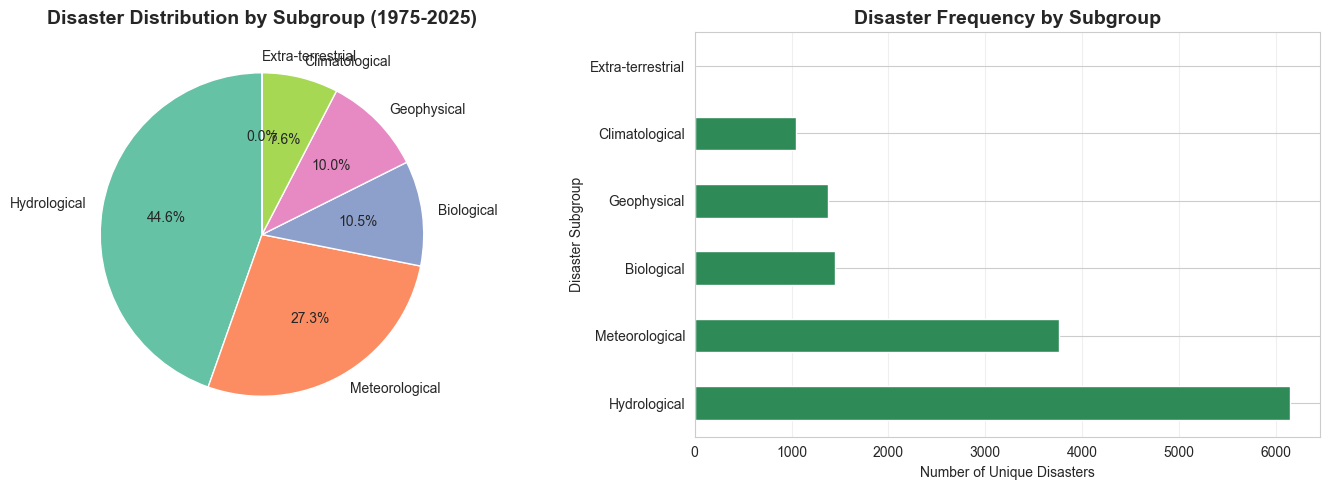


Disaster Subgroup Summary:


,Count,Percentage
Disaster Subgroup,,
Hydrological,6147,44.6
Meteorological,3760,27.3
Biological,1446,10.5
Geophysical,1380,10.0
Climatological,1049,7.6
Extra-terrestrial,1,0.0


In [4]:
subgroup_counts = df_clean.groupby('Disaster Subgroup')['Disaster_ID'].nunique().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
colors = sns.color_palette('Set2', n_colors=len(subgroup_counts))
ax1.pie(subgroup_counts.values, labels=subgroup_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax1.set_title(f'Disaster Distribution by Subgroup ({YEAR_START}-{YEAR_END})', fontsize=14, fontweight='bold')

# Bar chart
subgroup_counts.plot(kind='barh', ax=ax2, color='#2E8B57')
ax2.set_xlabel('Number of Unique Disasters')
ax2.set_title('Disaster Frequency by Subgroup', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nDisaster Subgroup Summary:')
pd.DataFrame({
    'Count': subgroup_counts,
    'Percentage': (subgroup_counts / subgroup_counts.sum() * 100).round(1)
})

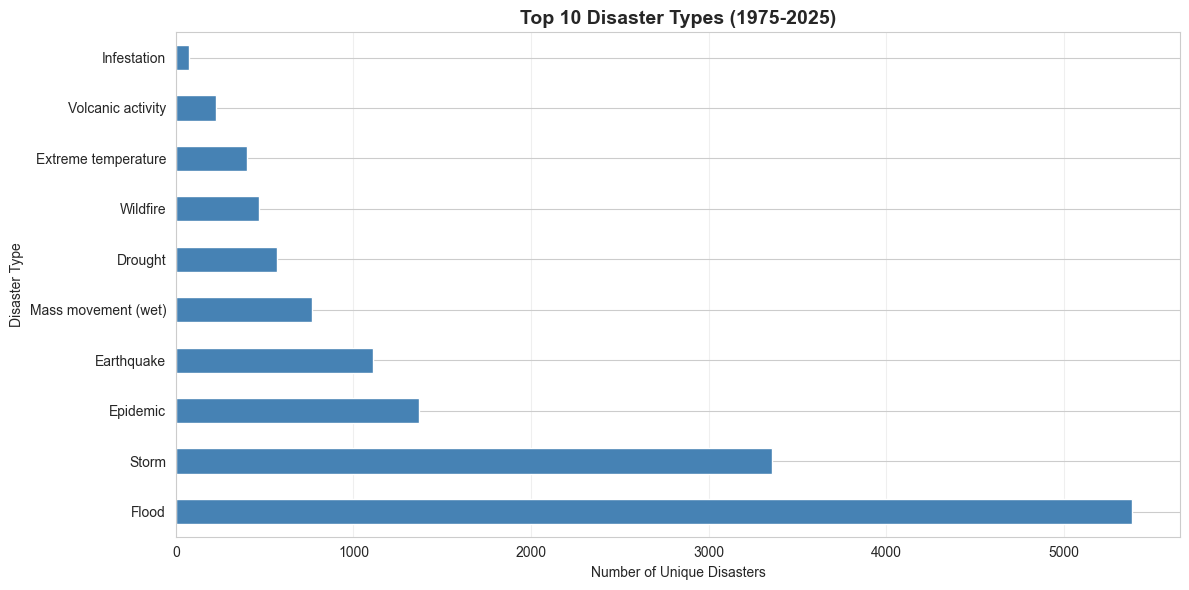


Top 5 Disaster Types:


,Count,Percentage
Disaster Type,,
Flood,5383,39.1
Storm,3357,24.4
Epidemic,1371,9.9
Earthquake,1112,8.1
Mass movement (wet),764,5.5


In [5]:
type_counts = df_clean.groupby('Disaster Type')['Disaster_ID'].nunique().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
type_counts.head(10).plot(kind='barh', color='#4682B4')
plt.xlabel('Number of Unique Disasters')
plt.title(f'Top 10 Disaster Types ({YEAR_START}-{YEAR_END})', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 5 Disaster Types:')
pd.DataFrame({
    'Count': type_counts.head(5),
    'Percentage': (type_counts.head(5) / type_counts.sum() * 100).round(1)
})

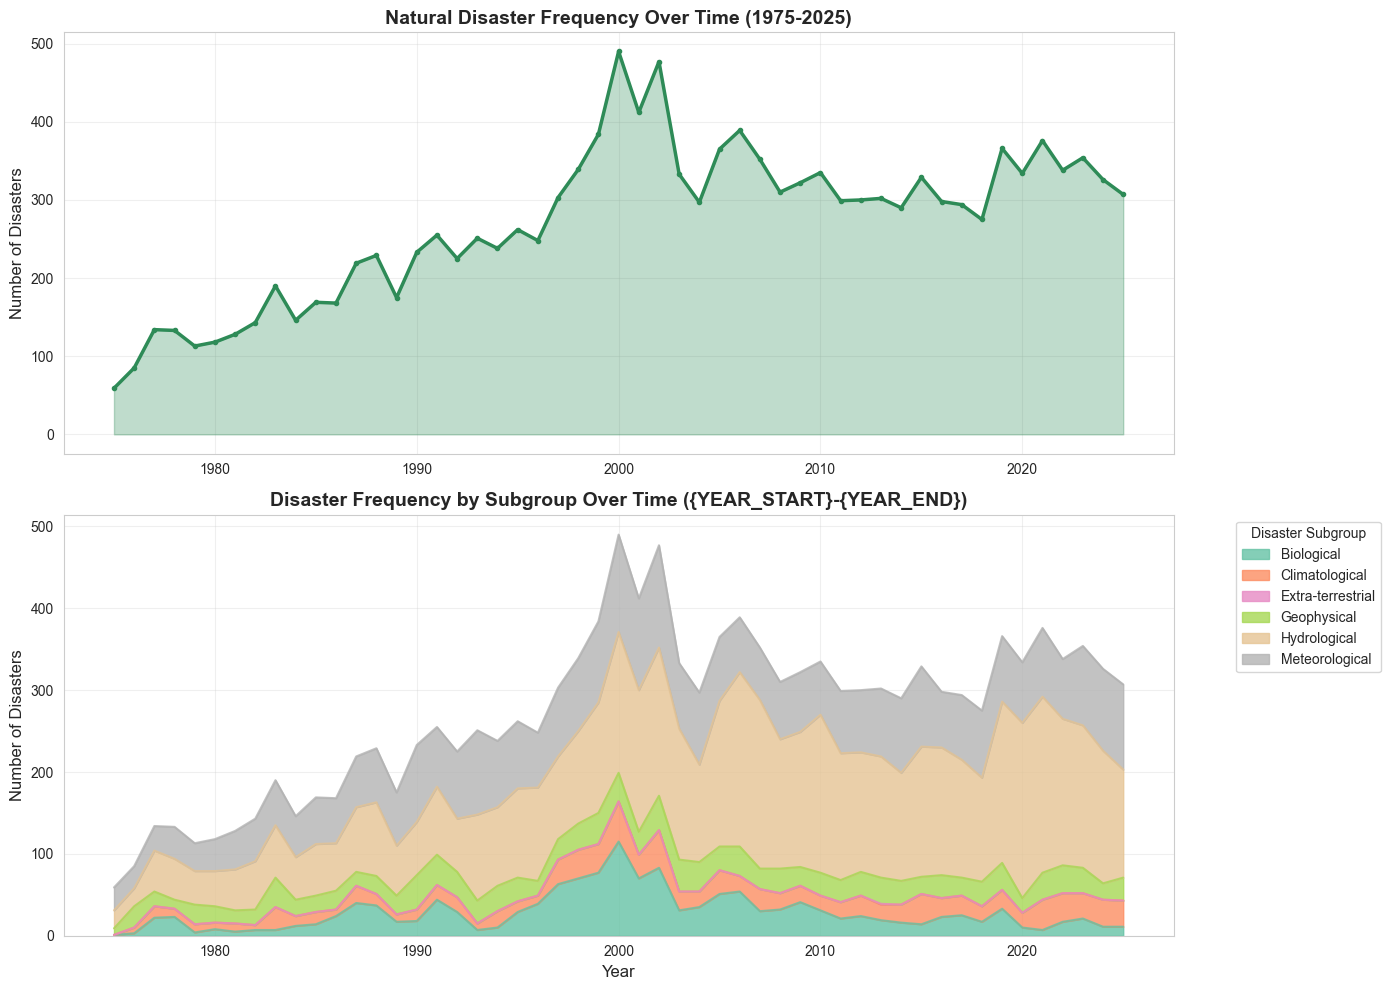

In [6]:
# Time series: Disaster frequency over time
disasters_per_year = df_clean.groupby('Start Year')['Disaster_ID'].nunique().sort_index()

disasters_by_subgroup_year = df_clean.groupby(['Start Year', 'Disaster Subgroup'])['Disaster_ID'].nunique().unstack(fill_value=0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.plot(disasters_per_year.index, disasters_per_year.values, color='#2E8B57', linewidth=2.5, marker='o', markersize=3)
ax1.fill_between(disasters_per_year.index, disasters_per_year.values, alpha=0.3, color='#2E8B57')
ax1.set_ylabel('Number of Disasters', fontsize=12)
ax1.set_title(f'Natural Disaster Frequency Over Time ({YEAR_START}-{YEAR_END})', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)

# Stacked area by subgroup
disasters_by_subgroup_year.plot(kind='area', stacked=True, ax=ax2, alpha=0.8, colormap='Set2')
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Disasters', fontsize=12)
ax2.set_title('Disaster Frequency by Subgroup Over Time ({YEAR_START}-{YEAR_END})', fontsize=14, fontweight='bold')
ax2.legend(title='Disaster Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

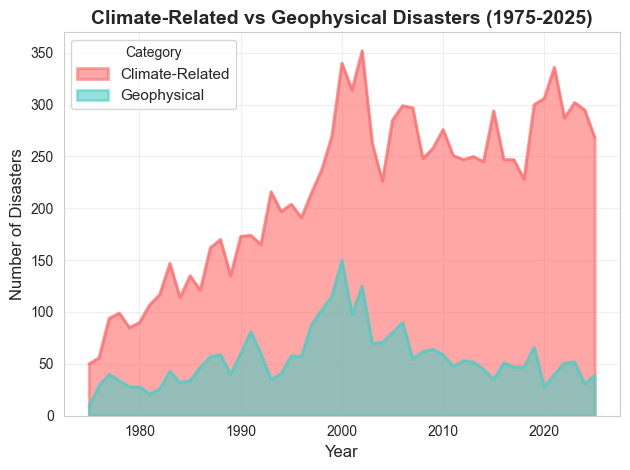


Climate-Related Disasters:
  1975-1980 average: 79.0/year
  2020-2025 average: 299.0/year
  Change: +278.5%

Geophysical Disasters:
  1975-1980 average: 28.0/year
  2020-2025 average: 40.2/year
  Change: +43.5%


In [7]:
# Climate-related vs Geological disasters trend
climate_related = ['Meteorological', 'Hydrological', 'Climatological']
df_clean['Disaster_Category'] = df_clean['Disaster Subgroup'].apply(
    lambda x: 'Climate-Related' if x in climate_related else 'Geophysical'
)

category_trend = df_clean.groupby(['Start Year', 'Disaster_Category'])['Disaster_ID'].nunique().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
category_trend.plot(kind='area', stacked=False, alpha=0.6, color=['#FF6B6B', '#4ECDC4'], linewidth=2)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Disasters', fontsize=12)
plt.title('Climate-Related vs Geophysical Disasters (1975-2025)', fontsize=14, fontweight='bold')
plt.legend(title='Category', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate percentage increase
climate_1975_1980 = category_trend.loc[1975:1980, 'Climate-Related'].mean()
climate_2020_2025 = category_trend.loc[2020:2025, 'Climate-Related'].mean()
geo_1975_1980 = category_trend.loc[1975:1980, 'Geophysical'].mean()
geo_2020_2025 = category_trend.loc[2020:2025, 'Geophysical'].mean()

print(f'\nClimate-Related Disasters:')
print(f'  1975-1980 average: {climate_1975_1980:.1f}/year')
print(f'  2020-2025 average: {climate_2020_2025:.1f}/year')
print(f'  Change: +{((climate_2020_2025/climate_1975_1980 - 1) * 100):.1f}%')
print(f'\nGeophysical Disasters:')
print(f'  1975-1980 average: {geo_1975_1980:.1f}/year')
print(f'  2020-2025 average: {geo_2020_2025:.1f}/year')
print(f'  Change: {((geo_2020_2025/geo_1975_1980 - 1) * 100):+.1f}%')

## 3. Geospatial Vulnerability Analysis

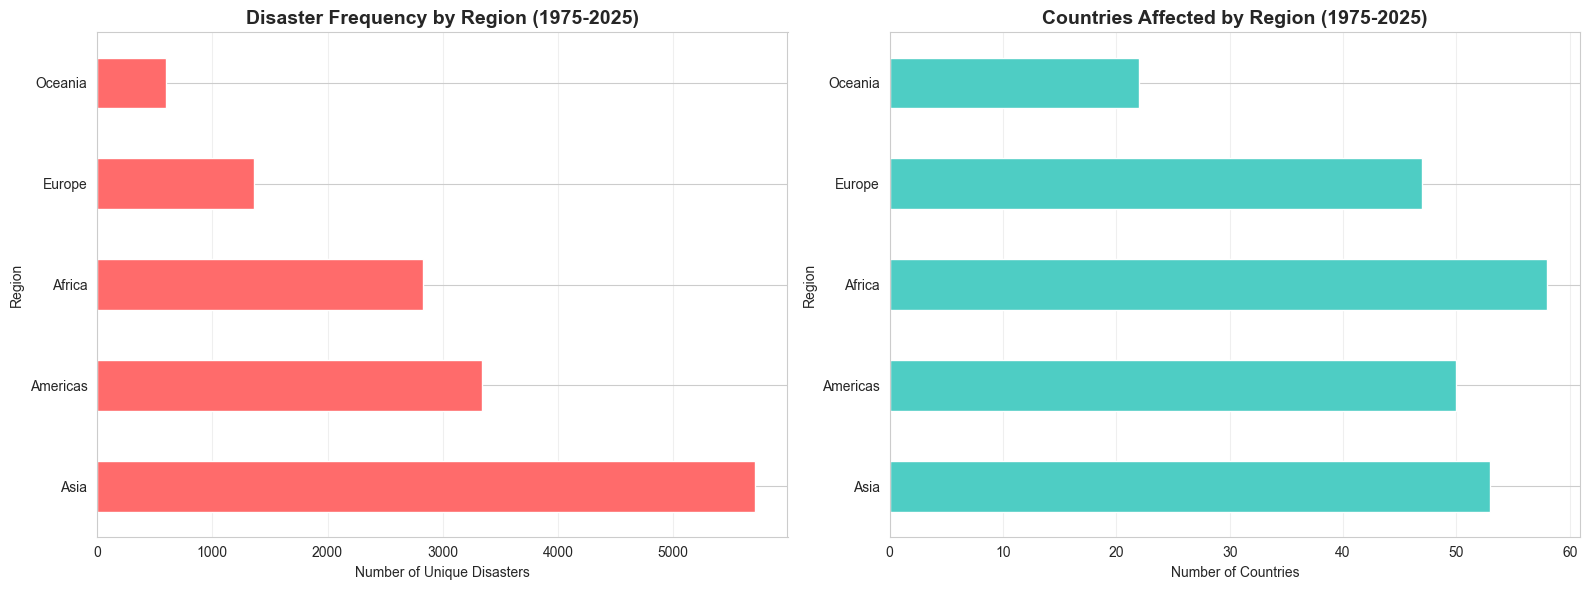


Regional Summary:


,Total Records,Unique Disasters,Countries Affected
Region,,,
Asia,6257,5705,53
Americas,3836,3343,50
Africa,3097,2825,58
Europe,2043,1358,47
Oceania,638,600,22


In [8]:
regional_disasters = df_clean.groupby('Region').agg({
    'DisNo.': 'count',
    'Disaster_ID': 'nunique',
    'Country': 'nunique'
}).rename(columns={
    'DisNo.': 'Total Records',
    'Disaster_ID': 'Unique Disasters',
    'Country': 'Countries Affected'
}).sort_values('Unique Disasters', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

regional_disasters['Unique Disasters'].plot(kind='barh', ax=ax1, color='#FF6B6B')
ax1.set_xlabel('Number of Unique Disasters')
ax1.set_title(f'Disaster Frequency by Region ({YEAR_START}-{YEAR_END})', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

regional_disasters['Countries Affected'].plot(kind='barh', ax=ax2, color='#4ECDC4')
ax2.set_xlabel('Number of Countries')
ax2.set_title(f'Countries Affected by Region ({YEAR_START}-{YEAR_END})', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nRegional Summary:')
regional_disasters

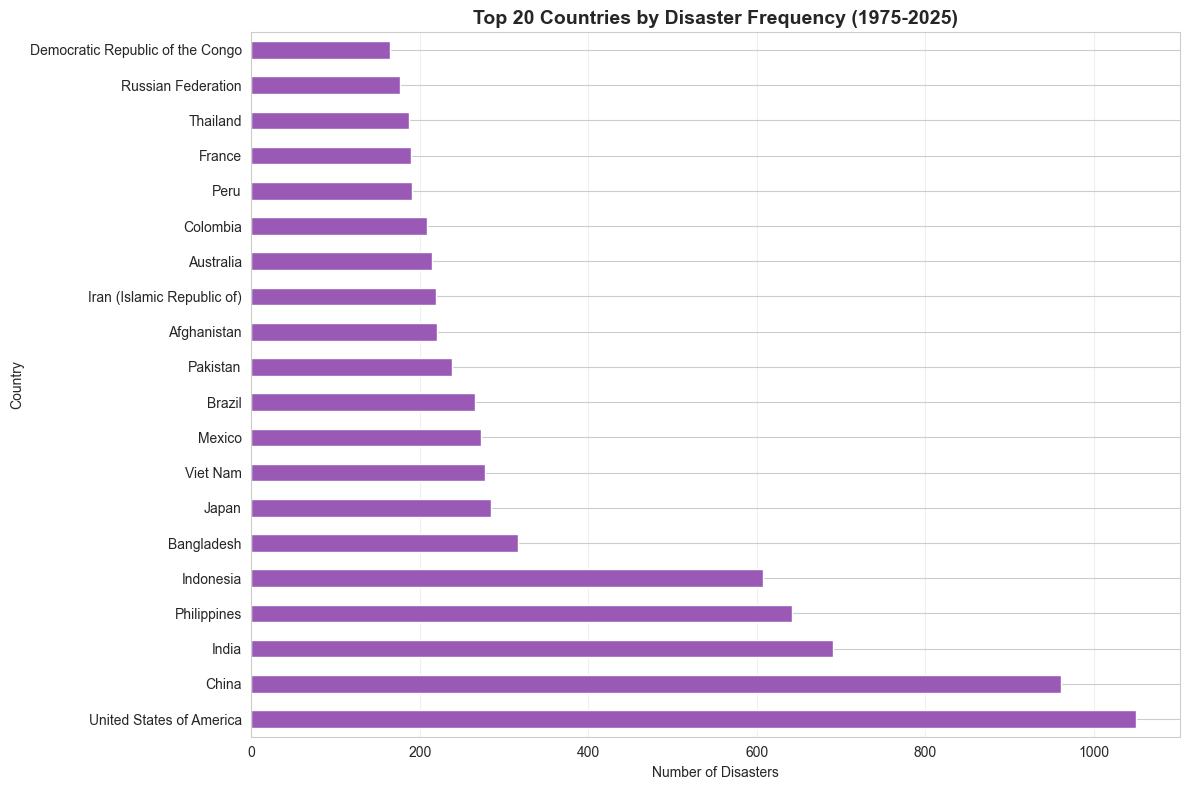


Top 10 Most Disaster-Prone Countries:


,Total Disasters,Total Deaths,Total Affected,Economic Damage ($1000s)
Country,,,,
United States of America,1050,19709.0,1.157636e+08,2.388961e+09
China,961,429481.0,3.276800e+09,1.033857e+09
India,691,199769.0,2.176853e+09,2.311718e+08
Philippines,642,58425.0,3.178275e+08,4.796731e+07
Indonesia,607,205024.0,5.805780e+07,5.738188e+07
Bangladesh,316,196607.0,4.365982e+08,4.063050e+07
Japan,285,32169.0,9.760948e+06,8.741372e+08
Viet Nam,277,18407.0,1.050284e+08,3.579778e+07
Mexico,273,17459.0,2.136744e+07,1.057923e+08


In [9]:
# Top 20 countries by disaster frequency
country_disasters = df_clean.groupby('Country').agg({
    'Disaster_ID': 'nunique',
    'Total Deaths': 'sum',
    'Total Affected': 'sum',
    'Total Damage, Adjusted (\'000 US$)': 'sum'
}).rename(columns={
    'Disaster_ID': 'Total Disasters',
    'Total Deaths': 'Total Deaths',
    'Total Affected': 'Total Affected',
    'Total Damage, Adjusted (\'000 US$)': 'Economic Damage ($1000s)'
}).sort_values('Total Disasters', ascending=False)

plt.figure(figsize=(12, 8))
country_disasters['Total Disasters'].head(20).plot(kind='barh', color='#9B59B6')
plt.xlabel('Number of Disasters')
plt.title('Top 20 Countries by Disaster Frequency (1975-2025)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop 10 Most Disaster-Prone Countries:')
country_disasters.head(10)

In [10]:
# Most frequent disaster type by country (for globe coloring)
country_primary_disaster = df_clean.groupby(['Country', 'ISO', 'Disaster Type']).size().reset_index(name='count')
country_primary_disaster = country_primary_disaster.loc[
    country_primary_disaster.groupby('Country')['count'].idxmax()
][['Country', 'ISO', 'Disaster Type', 'count']].rename(columns={'Disaster Type': 'Primary Disaster Type'})

# Merge with disaster counts
country_summary = country_disasters.reset_index().merge(
    country_primary_disaster[['Country', 'ISO', 'Primary Disaster Type']], 
    on='Country', 
    how='left'
)

print('Country Summary with Primary Disaster Type:')
country_summary.head(15)

Country Summary with Primary Disaster Type:


,Country,Total Disasters,Total Deaths,Total Affected,Economic Damage ($1000s),ISO,Primary Disaster Type
0,United States of America,1050,19709.0,1.157636e+08,2.388961e+09,USA,Storm
1,China,961,429481.0,3.276800e+09,1.033857e+09,CHN,Storm
2,India,691,199769.0,2.176853e+09,2.311718e+08,IND,Flood
3,Philippines,642,58425.0,3.178275e+08,4.796731e+07,PHL,Storm
4,Indonesia,607,205024.0,5.805780e+07,5.738188e+07,IDN,Flood
5,Bangladesh,316,196607.0,4.365982e+08,4.063050e+07,BGD,Storm
6,Japan,285,32169.0,9.760948e+06,8.741372e+08,JPN,Storm
7,Viet Nam,277,18407.0,1.050284e+08,3.579778e+07,VNM,Storm
8,Mexico,273,17459.0,2.136744e+07,1.057923e+08,MEX,Storm
9,Brazil,266,8535.0,1.059966e+08,8.161844e+07,BRA,Flood


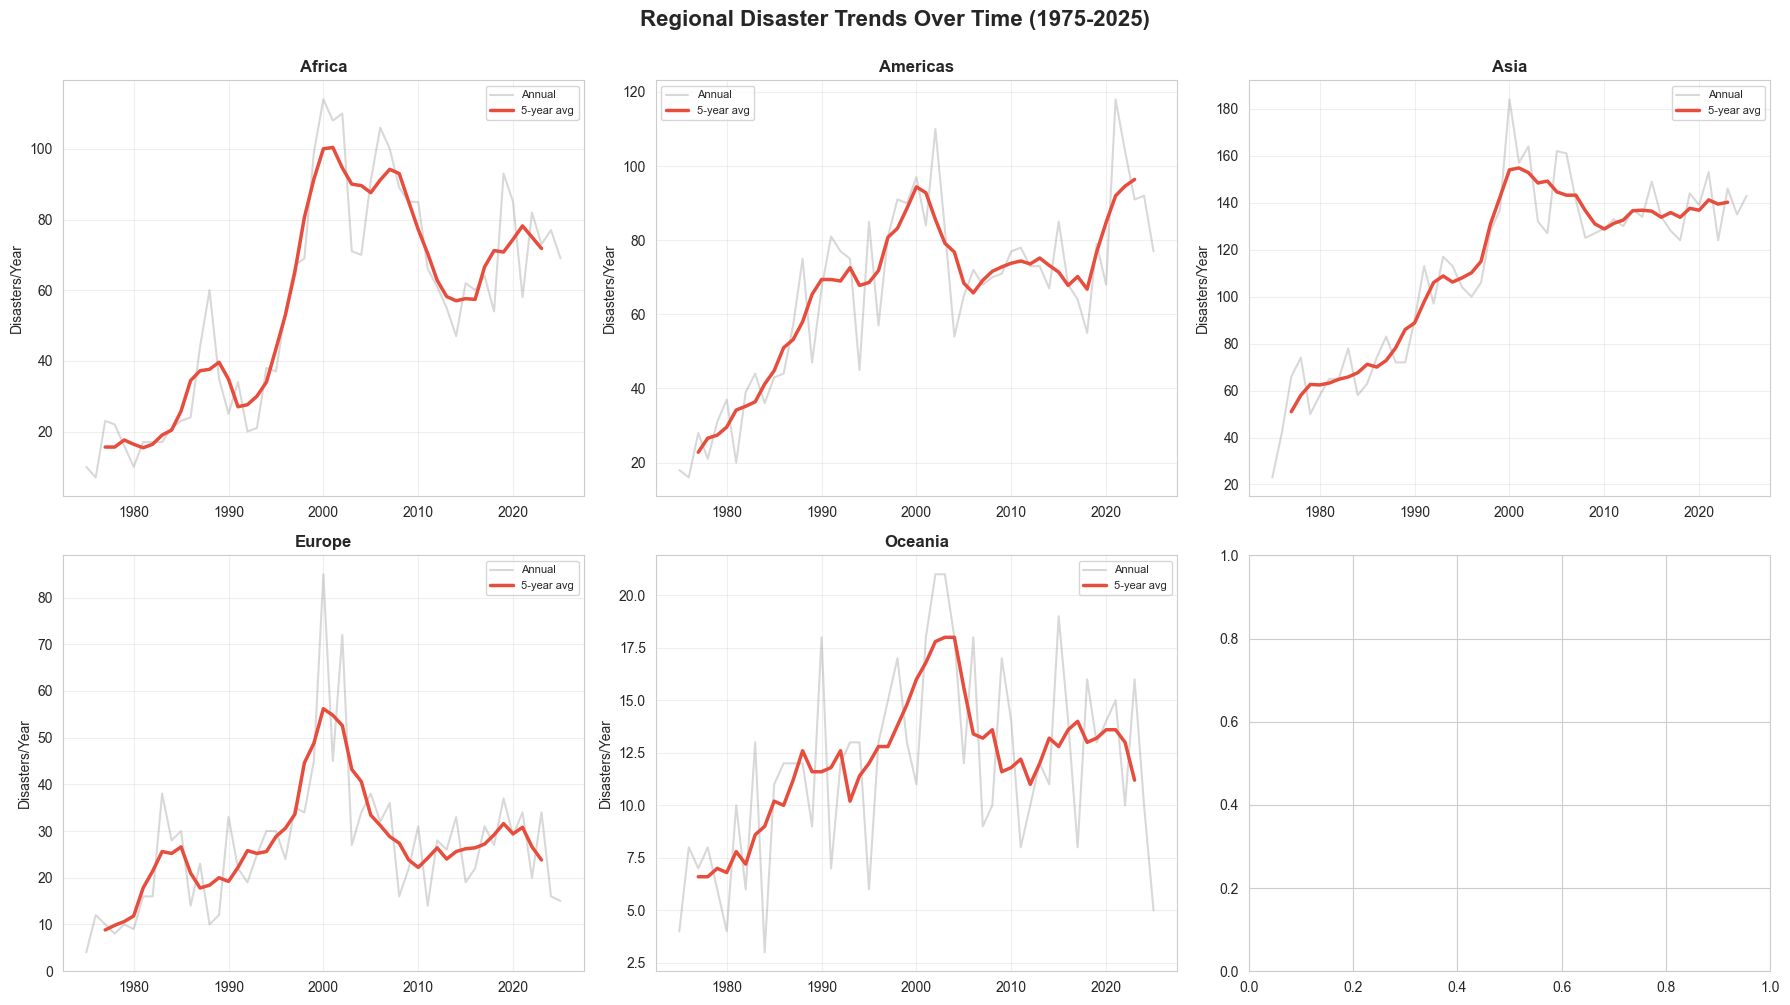

In [11]:
# Regional vulnerability over time (emerging vs traditional hotspots)
regional_timeline = df_clean.groupby(['Start Year', 'Region'])['Disaster_ID'].nunique().unstack(fill_value=0)

# Calculate 5-year moving averages for smoother trends
regional_timeline_smooth = regional_timeline.rolling(window=5, center=True).mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, region in enumerate(regional_timeline.columns):
    if idx < len(axes):
        ax = axes[idx]
        ax.plot(regional_timeline.index, regional_timeline[region], alpha=0.3, color='gray', label='Annual')
        ax.plot(regional_timeline_smooth.index, regional_timeline_smooth[region], 
                linewidth=2.5, color='#E74C3C', label='5-year avg')
        ax.set_title(region, fontsize=12, fontweight='bold')
        ax.set_ylabel('Disasters/Year')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

plt.suptitle('Regional Disaster Trends Over Time (1975-2025)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 4. Human Impact & Resilience Metrics

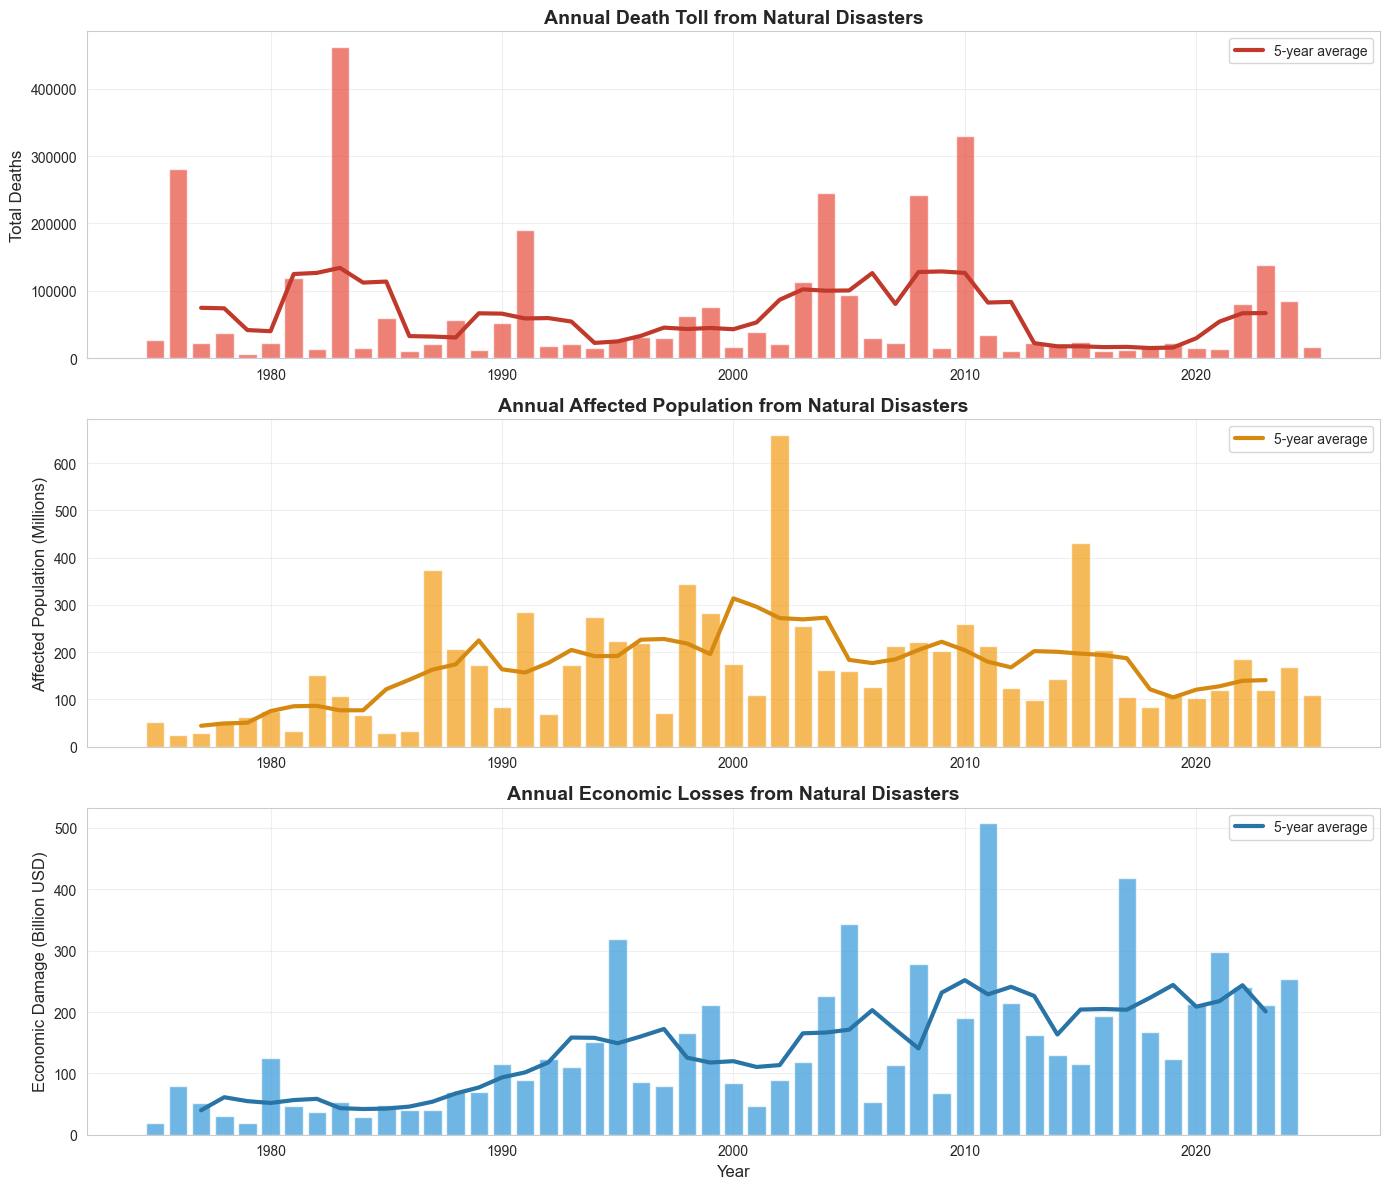


Total Impact (1975-2025):
  Deaths: 3,393,834
  Affected: 8,352,617,594 people
  Economic Damage: $7,078.7 billion


In [12]:
# Deaths over time
deaths_per_year = df_clean.groupby('Start Year')['Total Deaths'].sum().fillna(0)
affected_per_year = df_clean.groupby('Start Year')['Total Affected'].sum().fillna(0)
damage_per_year = df_clean.groupby('Start Year')['Total Damage, Adjusted (\'000 US$)'].sum().fillna(0)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].bar(deaths_per_year.index, deaths_per_year.values, color='#E74C3C', alpha=0.7)
axes[0].plot(deaths_per_year.index, deaths_per_year.rolling(5, center=True).mean(), 
             color='#C0392B', linewidth=3, label='5-year average')
axes[0].set_ylabel('Total Deaths', fontsize=12)
axes[0].set_title('Annual Death Toll from Natural Disasters', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Affected population
axes[1].bar(affected_per_year.index, affected_per_year.values / 1e6, color='#F39C12', alpha=0.7)
axes[1].plot(affected_per_year.index, (affected_per_year / 1e6).rolling(5, center=True).mean(), 
             color='#D68910', linewidth=3, label='5-year average')
axes[1].set_ylabel('Affected Population (Millions)', fontsize=12)
axes[1].set_title('Annual Affected Population from Natural Disasters', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Economic damage
axes[2].bar(damage_per_year.index, damage_per_year.values / 1e6, color='#3498DB', alpha=0.7)
axes[2].plot(damage_per_year.index, (damage_per_year / 1e6).rolling(5, center=True).mean(), 
             color='#2874A6', linewidth=3, label='5-year average')
axes[2].set_xlabel('Year', fontsize=12)
axes[2].set_ylabel('Economic Damage (Billion USD)', fontsize=12)
axes[2].set_title('Annual Economic Losses from Natural Disasters', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nTotal Impact (1975-2025):')
print(f'  Deaths: {deaths_per_year.sum():,.0f}')
print(f'  Affected: {affected_per_year.sum():,.0f} people')
print(f'  Economic Damage: ${damage_per_year.sum()/1e6:,.1f} billion')

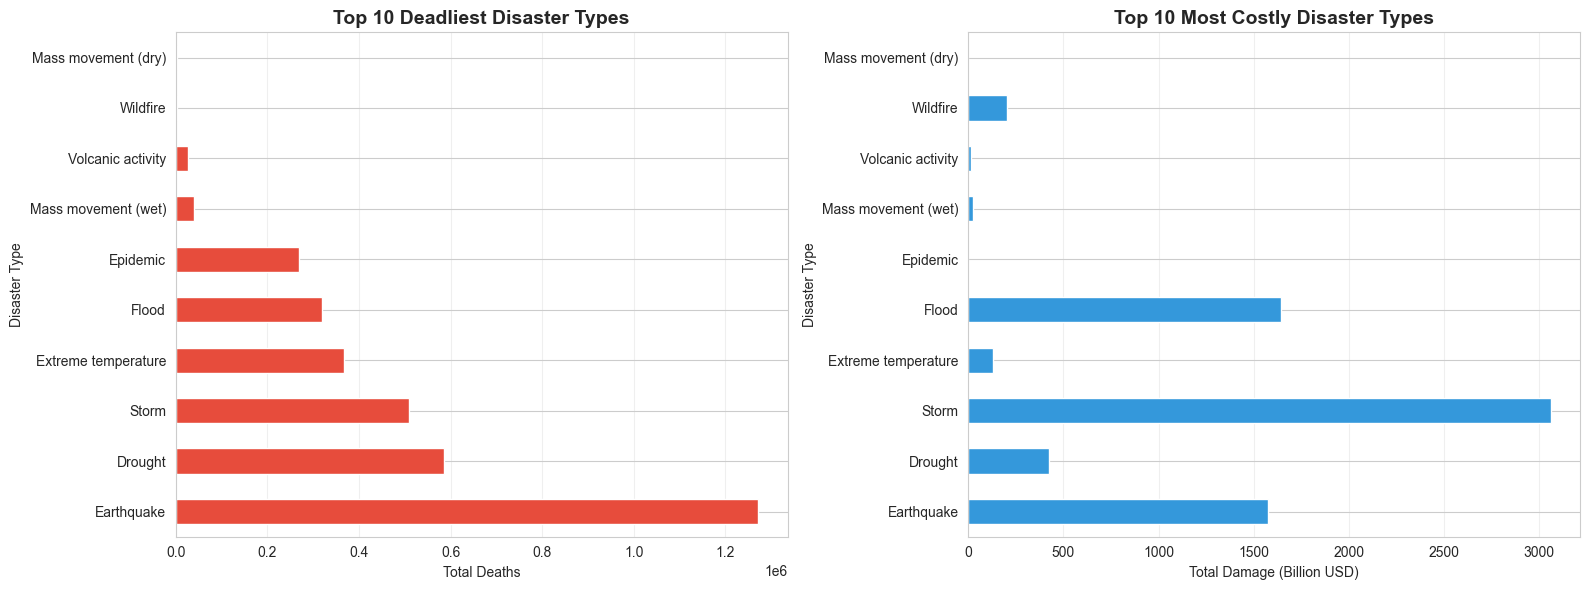


Top 10 Disaster Types by Deaths:


,Events,Deaths,Affected
Disaster Type,,,
Earthquake,1112,1271837.0,2.256581e+08
Drought,572,584703.0,2.664075e+09
Storm,3357,508806.0,1.322474e+09
Extreme temperature,403,368174.0,1.410856e+08
Flood,5383,319864.0,3.921872e+09
Epidemic,1371,268228.0,3.020440e+07
Mass movement (wet),764,38703.0,1.448695e+07
Volcanic activity,229,27246.0,1.020138e+07
Wildfire,470,3601.0,1.893984e+07


In [13]:
# Impact by disaster type
impact_by_type = df_clean.groupby('Disaster Type').agg({
    'Disaster_ID': 'nunique',
    'Total Deaths': 'sum',
    'Total Affected': 'sum',
    'Total Damage, Adjusted (\'000 US$)': 'sum'
}).rename(columns={
    'Disaster_ID': 'Events',
    'Total Deaths': 'Deaths',
    'Total Affected': 'Affected',
    'Total Damage, Adjusted (\'000 US$)': 'Damage ($1000s)'
}).sort_values('Deaths', ascending=False)

# Top 10 deadliest disaster types
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

impact_by_type['Deaths'].head(10).plot(kind='barh', ax=ax1, color='#E74C3C')
ax1.set_xlabel('Total Deaths')
ax1.set_title('Top 10 Deadliest Disaster Types', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

(impact_by_type['Damage ($1000s)'] / 1e6).head(10).plot(kind='barh', ax=ax2, color='#3498DB')
ax2.set_xlabel('Total Damage (Billion USD)')
ax2.set_title('Top 10 Most Costly Disaster Types', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nTop 10 Disaster Types by Deaths:')
impact_by_type[['Events', 'Deaths', 'Affected']].head(10)

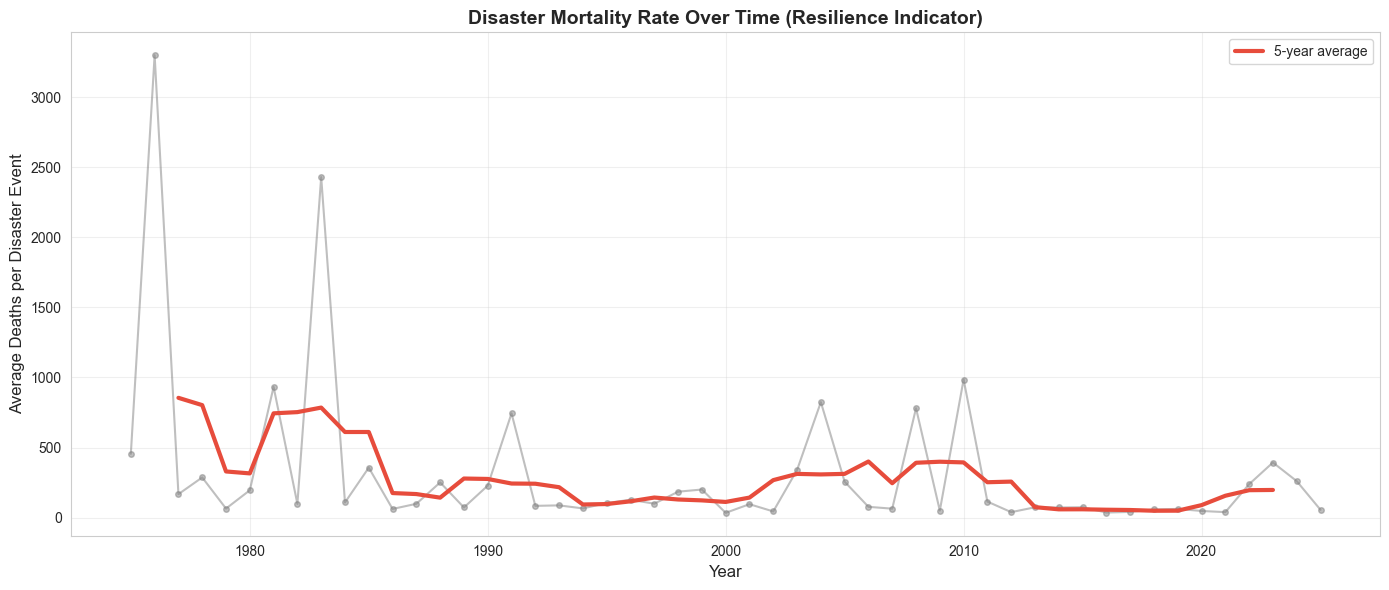


Mortality Rate Trend:
  1975-1985: 763.1 deaths/event
  2015-2025: 118.5 deaths/event
  Change: -84.5%


In [14]:
# Resilience indicator: Deaths per disaster event over time
deaths_per_event = df_clean.groupby('Start Year').agg({
    'Total Deaths': 'sum',
    'Disaster_ID': 'nunique'
})
deaths_per_event['Deaths per Event'] = deaths_per_event['Total Deaths'] / deaths_per_event['Disaster_ID']

plt.figure(figsize=(14, 6))
plt.plot(deaths_per_event.index, deaths_per_event['Deaths per Event'], 
         marker='o', markersize=4, alpha=0.5, color='gray')
plt.plot(deaths_per_event.index, deaths_per_event['Deaths per Event'].rolling(5, center=True).mean(), 
         linewidth=3, color='#E74C3C', label='5-year average')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Deaths per Disaster Event', fontsize=12)
plt.title('Disaster Mortality Rate Over Time (Resilience Indicator)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate trend
early_avg = deaths_per_event.loc[1975:1985, 'Deaths per Event'].mean()
recent_avg = deaths_per_event.loc[2015:2025, 'Deaths per Event'].mean()
print(f'\nMortality Rate Trend:')
print(f'  1975-1985: {early_avg:.1f} deaths/event')
print(f'  2015-2025: {recent_avg:.1f} deaths/event')
print(f'  Change: {((recent_avg/early_avg - 1) * 100):+.1f}%')

## 5. Key Relationships & Correlations

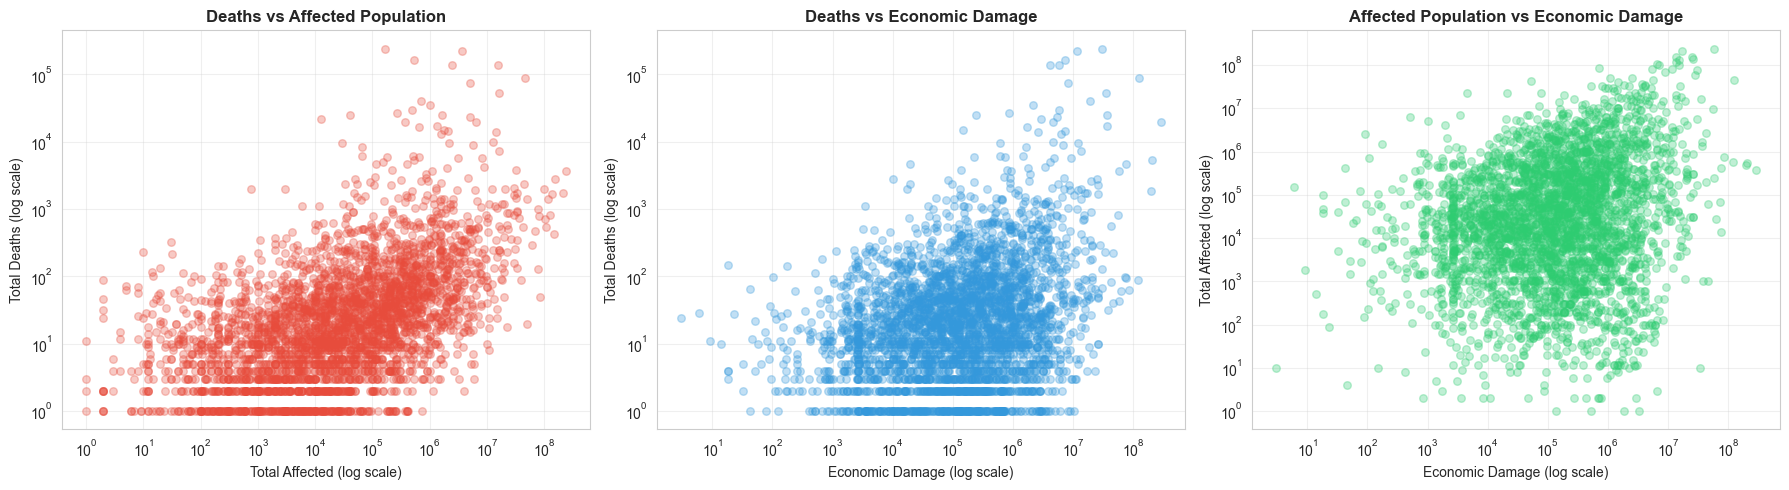


Correlation Matrix (log-transformed):
                                   Total Deaths  Total Affected  \
Total Deaths                              1.000           0.520   
Total Affected                            0.520           1.000   
Total Damage, Adjusted ('000 US$)         0.296           0.201   

                                   Total Damage, Adjusted ('000 US$)  
Total Deaths                                                   0.296  
Total Affected                                                 0.201  
Total Damage, Adjusted ('000 US$)                              1.000  


In [15]:
# Scatter plots: Impact relationships
df_impact = df_clean[[
    'Total Deaths', 'Total Affected', 'Total Damage, Adjusted (\'000 US$)'
]].dropna()

# Filter positive values for log scale
df_impact = df_impact[
    (df_impact['Total Deaths'] > 0) & 
    (df_impact['Total Affected'] > 0) & 
    (df_impact['Total Damage, Adjusted (\'000 US$)'] > 0)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Deaths vs Affected
axes[0].scatter(df_impact['Total Affected'], df_impact['Total Deaths'], 
                alpha=0.3, s=30, color='#E74C3C')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Total Affected (log scale)')
axes[0].set_ylabel('Total Deaths (log scale)')
axes[0].set_title('Deaths vs Affected Population', fontweight='bold')
axes[0].grid(alpha=0.3)

# Deaths vs Damage
axes[1].scatter(df_impact['Total Damage, Adjusted (\'000 US$)'], df_impact['Total Deaths'], 
                alpha=0.3, s=30, color='#3498DB')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Economic Damage (log scale)')
axes[1].set_ylabel('Total Deaths (log scale)')
axes[1].set_title('Deaths vs Economic Damage', fontweight='bold')
axes[1].grid(alpha=0.3)

# Affected vs Damage
axes[2].scatter(df_impact['Total Damage, Adjusted (\'000 US$)'], df_impact['Total Affected'], 
                alpha=0.3, s=30, color='#2ECC71')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlabel('Economic Damage (log scale)')
axes[2].set_ylabel('Total Affected (log scale)')
axes[2].set_title('Affected Population vs Economic Damage', fontweight='bold')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation matrix
corr_matrix = df_impact.corr()
print('\nCorrelation Matrix (log-transformed):')
print(np.log10(df_impact + 1).corr().round(3))